# Notebook 5: MRI Dataset Preparation & PyTorch DataLoader

## Objective

This notebook prepares the RSNA Lumbar Spine Degenerative Classification
dataset for Swin UNETR training.

Major tasks:

- Environment setup
- Dataset verification
- CSV integration
- Disease-wise slice preparation
- PyTorch Dataset
- DataLoader
- Batch visualization

In [150]:
# ============================================================
# Standard Libraries
# ============================================================

import os
import sys
import random
import warnings

warnings.filterwarnings("ignore")

In [151]:
# ============================================================
# Scientific Libraries
# ============================================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import cv2

import pydicom

In [152]:
# ============================================================
# PyTorch
# ============================================================

import torch
import torchvision

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

print("Torch Version :", torch.__version__)
print("TorchVision :", torchvision.__version__)

Torch Version : 2.11.0+cu128
TorchVision : 0.26.0+cu128


In [153]:
# ============================================================
# GPU Information
# ============================================================

print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU :", torch.cuda.get_device_name(0))

    print("CUDA Version :", torch.version.cuda)

else:

    print("Running on CPU")

CUDA Available : True
GPU : NVIDIA GeForce RTX 2050
CUDA Version : 12.8


## Configure Project Paths

In [154]:
# ============================================================
# Project Root
# ============================================================

PROJECT_ROOT = r"D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project"

DATASET_DIR = os.path.join(
    PROJECT_ROOT,
    "dataset",
    "rsna-2024-lumbar-spine-degenerative-classification"
)

TRAIN_IMAGES = os.path.join(
    DATASET_DIR,
    "train_images"
)

TEST_IMAGES = os.path.join(
    DATASET_DIR,
    "test_images"
)

OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "outputs"
)

TABLE_DIR = os.path.join(
    OUTPUT_DIR,
    "tables"
)

FIGURE_DIR = os.path.join(
    OUTPUT_DIR,
    "figures"
)

LOG_DIR = os.path.join(
    OUTPUT_DIR,
    "logs"
)

os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

In [155]:
print(PROJECT_ROOT)

print(DATASET_DIR)

print(TRAIN_IMAGES)

D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project
D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\dataset\rsna-2024-lumbar-spine-degenerative-classification
D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\dataset\rsna-2024-lumbar-spine-degenerative-classification\train_images


In [156]:
print(os.listdir(DATASET_DIR))

['sample_submission.csv', 'test_images', 'test_series_descriptions.csv', 'train.csv', 'train_images', 'train_label_coordinates.csv', 'train_series_descriptions.csv']


## Load CSV Files

In [157]:
train_df = pd.read_csv(
    os.path.join(
        DATASET_DIR,
        "train.csv"
    )
)

series_df = pd.read_csv(
    os.path.join(
        DATASET_DIR,
        "train_series_descriptions.csv"
    )
)

coord_df = pd.read_csv(
    os.path.join(
        DATASET_DIR,
        "train_label_coordinates.csv"
    )
)

In [158]:
print("Train :", train_df.shape)

print("Series :", series_df.shape)

print("Coordinates :", coord_df.shape)

Train : (1975, 26)
Series : (6294, 3)
Coordinates : (48692, 7)


In [159]:
train_df.head()

,study_id,spinal_canal_stenosis_l1_l2,spinal_canal_stenosis_l2_l3,spinal_canal_stenosis_l3_l4,spinal_canal_stenosis_l4_l5,spinal_canal_stenosis_l5_s1,left_neural_foraminal_narrowing_l1_l2,left_neural_foraminal_narrowing_l2_l3,left_neural_foraminal_narrowing_l3_l4,left_neural_foraminal_narrowing_l4_l5,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
0,4003253,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
1,4646740,Normal/Mild,Normal/Mild,Moderate,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate,Normal/Mild
2,7143189,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
3,8785691,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
4,10728036,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild


In [160]:
series_df.head()

,study_id,series_id,series_description
0,4003253,702807833,Sagittal T2/STIR
1,4003253,1054713880,Sagittal T1
2,4003253,2448190387,Axial T2
3,4646740,3201256954,Axial T2
4,4646740,3486248476,Sagittal T1


In [161]:
coord_df.head()

,study_id,series_id,instance_number,condition,level,x,y
0,4003253,702807833,8,Spinal Canal Stenosis,L1/L2,322.831858,227.964602
1,4003253,702807833,8,Spinal Canal Stenosis,L2/L3,320.571429,295.714286
2,4003253,702807833,8,Spinal Canal Stenosis,L3/L4,323.030303,371.818182
3,4003253,702807833,8,Spinal Canal Stenosis,L4/L5,335.292035,427.327434
4,4003253,702807833,8,Spinal Canal Stenosis,L5/S1,353.415929,483.964602


## Dataset Summary

In [162]:
summary = pd.DataFrame({

    "Metric":[

        "Patients",

        "MRI Series",

        "Coordinate Labels",

        "Disease Conditions"

    ],

    "Value":[

        train_df.study_id.nunique(),

        len(series_df),

        len(coord_df),

        coord_df.condition.nunique()

    ]

})

summary

,Metric,Value
0,Patients,1975
1,MRI Series,6294
2,Coordinate Labels,48692
3,Disease Conditions,5


In [163]:
summary.to_csv(

    os.path.join(
        TABLE_DIR,
        "dataset_summary.csv"
    ),

    index=False

)

print("Summary Saved.")

Summary Saved.


In [164]:
print("="*60)

print("Notebook 5 - Module 1 Completed")

print("="*60)

print(summary)

Notebook 5 - Module 1 Completed
               Metric  Value
0            Patients   1975
1          MRI Series   6294
2   Coordinate Labels  48692
3  Disease Conditions      5


# Module 1 Summary

Completed:

- Imported all required libraries
- Checked GPU
- Configured project paths
- Loaded dataset
- Loaded CSV files
- Verified dataset
- Created summary table

Next Module:

## Module 2

Dataset Integration

We will combine:

- train.csv
- train_series_descriptions.csv
- train_label_coordinates.csv

into one master dataframe for disease-wise MRI slice selection.

# Module 2: Dataset Integration

## Objective

This module combines all metadata files into a single master dataframe.

Files used:

- train.csv
- train_series_descriptions.csv
- train_label_coordinates.csv

The resulting dataframe will contain all information required for
disease-aware MRI slice loading.

In [165]:
# ============================================================
# Check DataFrames
# ============================================================

print("Train :", train_df.shape)
print("Series :", series_df.shape)
print("Coordinates :", coord_df.shape)

Train : (1975, 26)
Series : (6294, 3)
Coordinates : (48692, 7)


In [166]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1975 entries, 0 to 1974
Data columns (total 26 columns):
 #   Column                                  Non-Null Count  Dtype 
---  ------                                  --------------  ----- 
 0   study_id                                1975 non-null   int64 
 1   spinal_canal_stenosis_l1_l2             1974 non-null   object
 2   spinal_canal_stenosis_l2_l3             1974 non-null   object
 3   spinal_canal_stenosis_l3_l4             1974 non-null   object
 4   spinal_canal_stenosis_l4_l5             1974 non-null   object
 5   spinal_canal_stenosis_l5_s1             1974 non-null   object
 6   left_neural_foraminal_narrowing_l1_l2   1973 non-null   object
 7   left_neural_foraminal_narrowing_l2_l3   1973 non-null   object
 8   left_neural_foraminal_narrowing_l3_l4   1973 non-null   object
 9   left_neural_foraminal_narrowing_l4_l5   1973 non-null   object
 10  left_neural_foraminal_narrowing_l5_s1   1973 non-null   object
 11  righ

In [167]:
series_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6294 entries, 0 to 6293
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   study_id            6294 non-null   int64 
 1   series_id           6294 non-null   int64 
 2   series_description  6294 non-null   object
dtypes: int64(2), object(1)
memory usage: 147.6+ KB


In [168]:
coord_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48692 entries, 0 to 48691
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   study_id         48692 non-null  int64  
 1   series_id        48692 non-null  int64  
 2   instance_number  48692 non-null  int64  
 3   condition        48692 non-null  object 
 4   level            48692 non-null  object 
 5   x                48692 non-null  float64
 6   y                48692 non-null  float64
dtypes: float64(2), int64(3), object(2)
memory usage: 2.6+ MB


## Unique Studies

In [169]:
print("Train Studies :", train_df.study_id.nunique())

print("Series Studies :", series_df.study_id.nunique())

print("Coordinate Studies :", coord_df.study_id.nunique())

Train Studies : 1975
Series Studies : 1975
Coordinate Studies : 1974


In [170]:
common = set(train_df.study_id) & \
         set(series_df.study_id) & \
         set(coord_df.study_id)

print("Common Studies :", len(common))

Common Studies : 1974


## Merge Series Information

In [171]:
series_df.head()

,study_id,series_id,series_description
0,4003253,702807833,Sagittal T2/STIR
1,4003253,1054713880,Sagittal T1
2,4003253,2448190387,Axial T2
3,4646740,3201256954,Axial T2
4,4646740,3486248476,Sagittal T1


In [172]:
master_df = coord_df.merge(

    series_df,

    on=["study_id","series_id"],

    how="left"

)

master_df.head()

,study_id,series_id,instance_number,condition,level,x,y,series_description
0,4003253,702807833,8,Spinal Canal Stenosis,L1/L2,322.831858,227.964602,Sagittal T2/STIR
1,4003253,702807833,8,Spinal Canal Stenosis,L2/L3,320.571429,295.714286,Sagittal T2/STIR
2,4003253,702807833,8,Spinal Canal Stenosis,L3/L4,323.030303,371.818182,Sagittal T2/STIR
3,4003253,702807833,8,Spinal Canal Stenosis,L4/L5,335.292035,427.327434,Sagittal T2/STIR
4,4003253,702807833,8,Spinal Canal Stenosis,L5/S1,353.415929,483.964602,Sagittal T2/STIR


In [173]:
print(master_df.shape)

(48692, 8)


In [174]:
master_df["encoded_label"] = ...

In [175]:
master_df.columns

Index(['study_id', 'series_id', 'instance_number', 'condition', 'level', 'x',
       'y', 'series_description', 'encoded_label'],
      dtype='object')

## Merge Patient Labels

In [176]:
master_df = master_df.merge(

    train_df,

    on="study_id",

    how="left"

)

master_df.head()

,study_id,series_id,instance_number,condition,level,x,y,series_description,encoded_label,spinal_canal_stenosis_l1_l2,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
0,4003253,702807833,8,Spinal Canal Stenosis,L1/L2,322.831858,227.964602,Sagittal T2/STIR,Ellipsis,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
1,4003253,702807833,8,Spinal Canal Stenosis,L2/L3,320.571429,295.714286,Sagittal T2/STIR,Ellipsis,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
2,4003253,702807833,8,Spinal Canal Stenosis,L3/L4,323.030303,371.818182,Sagittal T2/STIR,Ellipsis,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
3,4003253,702807833,8,Spinal Canal Stenosis,L4/L5,335.292035,427.327434,Sagittal T2/STIR,Ellipsis,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
4,4003253,702807833,8,Spinal Canal Stenosis,L5/S1,353.415929,483.964602,Sagittal T2/STIR,Ellipsis,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild


In [177]:
print(master_df.shape)

(48692, 34)


In [178]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48692 entries, 0 to 48691
Data columns (total 34 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   study_id                                48692 non-null  int64  
 1   series_id                               48692 non-null  int64  
 2   instance_number                         48692 non-null  int64  
 3   condition                               48692 non-null  object 
 4   level                                   48692 non-null  object 
 5   x                                       48692 non-null  float64
 6   y                                       48692 non-null  float64
 7   series_description                      48692 non-null  object 
 8   encoded_label                           48692 non-null  object 
 9   spinal_canal_stenosis_l1_l2             48692 non-null  object 
 10  spinal_canal_stenosis_l2_l3             48692 non-null  ob

## Missing Values

In [179]:
missing = master_df.isnull().sum()

missing = missing[missing > 0]

missing

left_neural_foraminal_narrowing_l1_l2       30
left_neural_foraminal_narrowing_l2_l3       30
left_neural_foraminal_narrowing_l3_l4       30
left_neural_foraminal_narrowing_l4_l5       30
left_neural_foraminal_narrowing_l5_s1       30
right_neural_foraminal_narrowing_l1_l2     180
right_neural_foraminal_narrowing_l2_l3     180
right_neural_foraminal_narrowing_l3_l4     180
right_neural_foraminal_narrowing_l4_l5     180
right_neural_foraminal_narrowing_l5_s1     180
left_subarticular_stenosis_l1_l2          3508
left_subarticular_stenosis_l2_l3          1651
left_subarticular_stenosis_l3_l4            65
left_subarticular_stenosis_l4_l5            69
left_subarticular_stenosis_l5_s1           252
right_subarticular_stenosis_l1_l2         3434
right_subarticular_stenosis_l2_l3         1647
right_subarticular_stenosis_l3_l4           40
right_subarticular_stenosis_l4_l5           44
right_subarticular_stenosis_l5_s1          155
dtype: int64

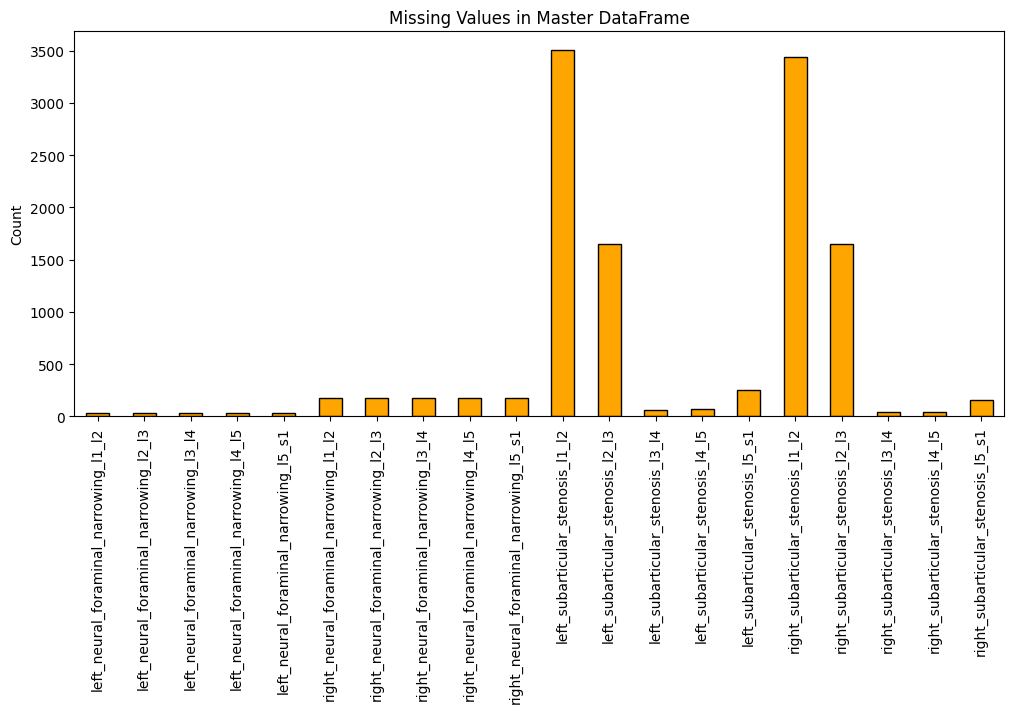

In [180]:
plt.figure(figsize=(12,5))

missing.plot(

    kind="bar",

    color="orange",

    edgecolor="black"

)

plt.title("Missing Values in Master DataFrame")

plt.ylabel("Count")

plt.show()

## MRI Sequence Distribution

In [181]:
master_df["series_description"].value_counts()

series_description
Sagittal T1         19724
Axial T2            19220
Sagittal T2/STIR     9748
Name: count, dtype: int64

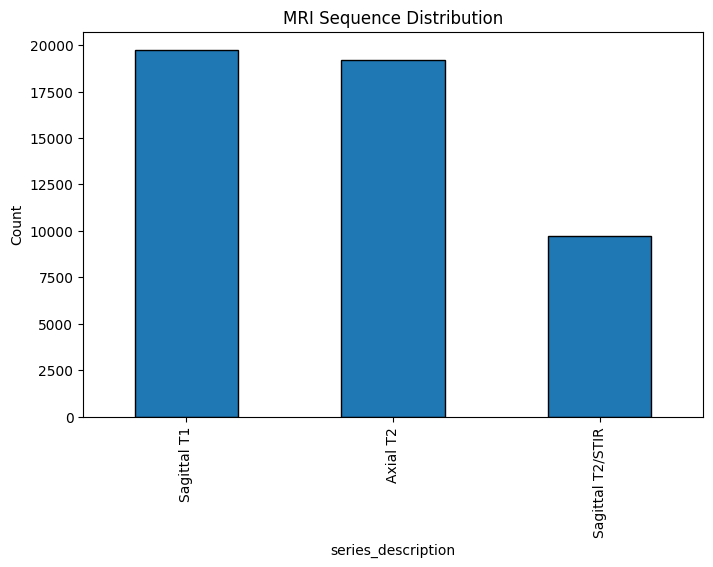

In [182]:
plt.figure(figsize=(8,5))

master_df["series_description"].value_counts().plot(

    kind="bar",

    edgecolor="black"

)

plt.title("MRI Sequence Distribution")

plt.ylabel("Count")

plt.show()

## Disease Distribution

In [183]:
master_df["condition"].value_counts()

condition
Left Neural Foraminal Narrowing     9860
Right Neural Foraminal Narrowing    9859
Spinal Canal Stenosis               9753
Right Subarticular Stenosis         9612
Left Subarticular Stenosis          9608
Name: count, dtype: int64

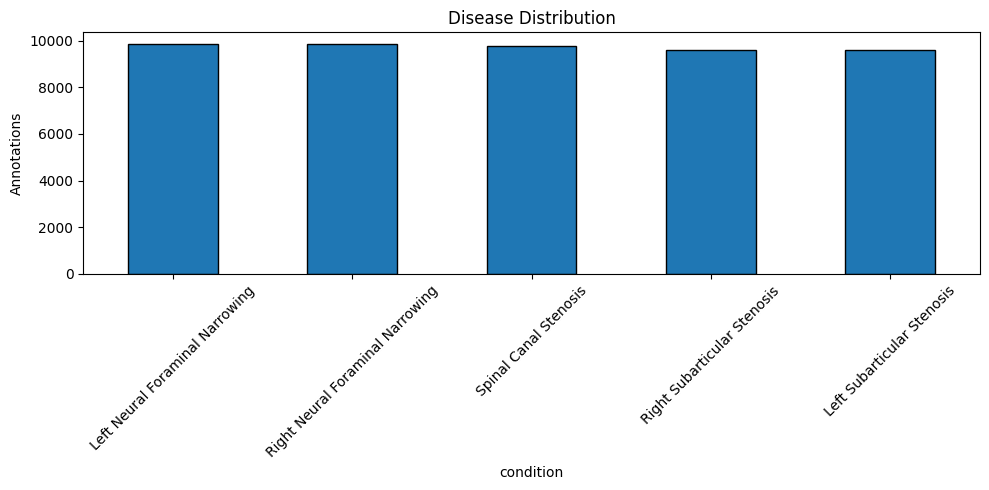

In [184]:
plt.figure(figsize=(10,5))

master_df["condition"].value_counts().plot(

    kind="bar",

    edgecolor="black"

)

plt.title("Disease Distribution")

plt.ylabel("Annotations")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Spine Level Distribution

In [185]:
master_df["level"].value_counts().sort_index()

level
L1/L2    9470
L2/L3    9661
L3/L4    9858
L4/L5    9858
L5/S1    9845
Name: count, dtype: int64

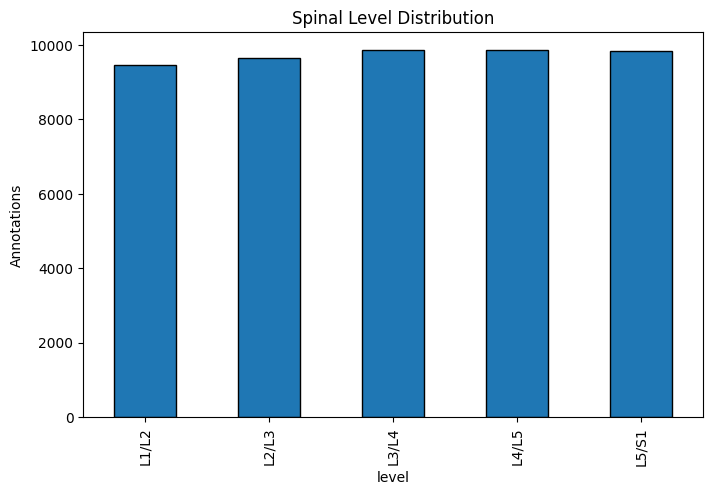

In [186]:
plt.figure(figsize=(8,5))

master_df["level"].value_counts().sort_index().plot(

    kind="bar",

    edgecolor="black"

)

plt.title("Spinal Level Distribution")

plt.ylabel("Annotations")

plt.show()

In [187]:
master_df.to_csv(

    os.path.join(
        TABLE_DIR,
        "master_dataframe.csv"
    ),

    index=False

)

print("Master DataFrame saved.")

Master DataFrame saved.


In [188]:
print(master_df.shape)

master_df.head()

(48692, 34)


,study_id,series_id,instance_number,condition,level,x,y,series_description,encoded_label,spinal_canal_stenosis_l1_l2,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
0,4003253,702807833,8,Spinal Canal Stenosis,L1/L2,322.831858,227.964602,Sagittal T2/STIR,Ellipsis,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
1,4003253,702807833,8,Spinal Canal Stenosis,L2/L3,320.571429,295.714286,Sagittal T2/STIR,Ellipsis,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
2,4003253,702807833,8,Spinal Canal Stenosis,L3/L4,323.030303,371.818182,Sagittal T2/STIR,Ellipsis,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
3,4003253,702807833,8,Spinal Canal Stenosis,L4/L5,335.292035,427.327434,Sagittal T2/STIR,Ellipsis,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
4,4003253,702807833,8,Spinal Canal Stenosis,L5/S1,353.415929,483.964602,Sagittal T2/STIR,Ellipsis,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild


In [189]:
summary = pd.DataFrame({

    "Metric":[
        "Patients",
        "Series",
        "Coordinate Labels",
        "Merged Records"
    ],

    "Value":[
        train_df.study_id.nunique(),
        series_df.series_id.nunique(),
        len(coord_df),
        len(master_df)
    ]

})

summary

,Metric,Value
0,Patients,1975
1,Series,6294
2,Coordinate Labels,48692
3,Merged Records,48692


In [190]:
summary.to_csv(

    os.path.join(
        TABLE_DIR,
        "master_summary.csv"
    ),

    index=False

)

In [191]:
print("="*60)

print("Module 2 Completed Successfully")

print("="*60)

Module 2 Completed Successfully


# Module 2 Summary

Completed:

- Verified metadata
- Merged coordinate and series information
- Merged patient labels
- Created master dataframe
- Analysed MRI sequence distribution
- Analysed disease distribution
- Saved master dataframe

Next Module:

**Module 3 – Disease-wise MRI Slice Selection**

In the next module, we will:

- Select MRI slices using `instance_number`
- Locate DICOM files
- Load disease-specific slices
- Visualize disease-wise MRI images
- Prepare inputs for the PyTorch Dataset

# Module 2 Summary

Completed:

- Verified metadata
- Merged coordinate and series information
- Merged patient labels
- Created master dataframe
- Analysed MRI sequence distribution
- Analysed disease distribution
- Saved master dataframe

Next Module:

**Module 3 – Disease-wise MRI Slice Selection**

In the next module, we will:

- Select MRI slices using `instance_number`
- Locate DICOM files
- Load disease-specific slices
- Visualize disease-wise MRI images
- Prepare inputs for the PyTorch Dataset

In [192]:
# ============================================================
# Display Master DataFrame
# ============================================================

print("Master DataFrame Shape :", master_df.shape)

master_df.head()

Master DataFrame Shape : (48692, 34)


,study_id,series_id,instance_number,condition,level,x,y,series_description,encoded_label,spinal_canal_stenosis_l1_l2,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
0,4003253,702807833,8,Spinal Canal Stenosis,L1/L2,322.831858,227.964602,Sagittal T2/STIR,Ellipsis,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
1,4003253,702807833,8,Spinal Canal Stenosis,L2/L3,320.571429,295.714286,Sagittal T2/STIR,Ellipsis,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
2,4003253,702807833,8,Spinal Canal Stenosis,L3/L4,323.030303,371.818182,Sagittal T2/STIR,Ellipsis,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
3,4003253,702807833,8,Spinal Canal Stenosis,L4/L5,335.292035,427.327434,Sagittal T2/STIR,Ellipsis,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
4,4003253,702807833,8,Spinal Canal Stenosis,L5/S1,353.415929,483.964602,Sagittal T2/STIR,Ellipsis,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild


In [193]:
print(master_df.columns)

Index(['study_id', 'series_id', 'instance_number', 'condition', 'level', 'x',
       'y', 'series_description', 'encoded_label',
       'spinal_canal_stenosis_l1_l2', 'spinal_canal_stenosis_l2_l3',
       'spinal_canal_stenosis_l3_l4', 'spinal_canal_stenosis_l4_l5',
       'spinal_canal_stenosis_l5_s1', 'left_neural_foraminal_narrowing_l1_l2',
       'left_neural_foraminal_narrowing_l2_l3',
       'left_neural_foraminal_narrowing_l3_l4',
       'left_neural_foraminal_narrowing_l4_l5',
       'left_neural_foraminal_narrowing_l5_s1',
       'right_neural_foraminal_narrowing_l1_l2',
       'right_neural_foraminal_narrowing_l2_l3',
       'right_neural_foraminal_narrowing_l3_l4',
       'right_neural_foraminal_narrowing_l4_l5',
       'right_neural_foraminal_narrowing_l5_s1',
       'left_subarticular_stenosis_l1_l2', 'left_subarticular_stenosis_l2_l3',
       'left_subarticular_stenosis_l3_l4', 'left_subarticular_stenosis_l4_l5',
       'left_subarticular_stenosis_l5_s1', 'right_subarticu

In [194]:
sample = master_df.iloc[0]

sample

study_id                                                4003253
series_id                                             702807833
instance_number                                               8
condition                                 Spinal Canal Stenosis
level                                                     L1/L2
x                                                    322.831858
y                                                    227.964602
series_description                             Sagittal T2/STIR
encoded_label                                          Ellipsis
spinal_canal_stenosis_l1_l2                         Normal/Mild
spinal_canal_stenosis_l2_l3                         Normal/Mild
spinal_canal_stenosis_l3_l4                         Normal/Mild
spinal_canal_stenosis_l4_l5                         Normal/Mild
spinal_canal_stenosis_l5_s1                         Normal/Mild
left_neural_foraminal_narrowing_l1_l2               Normal/Mild
left_neural_foraminal_narrowing_l2_l3   

print(master_df.columns)

In [195]:
study_id = int(sample.study_id)

series_id = int(sample.series_id)

instance_number = int(sample.instance_number)

condition = sample.condition

level = sample.level

print("Study ID :", study_id)
print("Series ID :", series_id)
print("Slice :", instance_number)
print("Condition :", condition)
print("Level :", level)

Study ID : 4003253
Series ID : 702807833
Slice : 8
Condition : Spinal Canal Stenosis
Level : L1/L2


## Locate MRI Series

In [196]:
series_folder = os.path.join(
    TRAIN_IMAGES,
    str(study_id),
    str(series_id)
)

print(series_folder)

D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\dataset\rsna-2024-lumbar-spine-degenerative-classification\train_images\4003253\702807833


In [197]:
print(os.path.exists(series_folder))

True


In [198]:
dicom_files = sorted(os.listdir(series_folder))

print("Total Slices :", len(dicom_files))

Total Slices : 15


In [199]:
dicom_files[:10]

['1.dcm',
 '10.dcm',
 '11.dcm',
 '12.dcm',
 '13.dcm',
 '14.dcm',
 '15.dcm',
 '2.dcm',
 '3.dcm',
 '4.dcm']

## Locate the Annotated Slice

In [200]:
slice_name = f"{instance_number}.dcm"

print(slice_name)

8.dcm


In [201]:
slice_path = os.path.join(
    series_folder,
    slice_name
)

print(slice_path)

D:\Msc Major Project Swin Unetr Framework\MSc_SwinUNETR_Project\dataset\rsna-2024-lumbar-spine-degenerative-classification\train_images\4003253\702807833\8.dcm


In [202]:
print(os.path.exists(slice_path))

True


In [203]:
dicom = pydicom.dcmread(slice_path)

image = dicom.pixel_array

print(image.shape)

(640, 640)


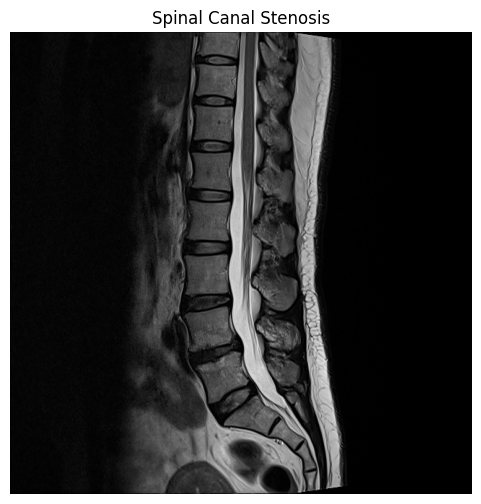

In [204]:
plt.figure(figsize=(6,6))

plt.imshow(image, cmap="gray")

plt.title(condition)

plt.axis("off")

plt.show()

## Display Annotation Point

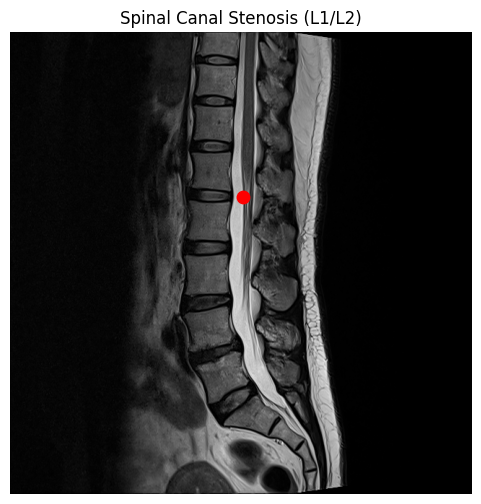

In [205]:
plt.figure(figsize=(6,6))

plt.imshow(image, cmap="gray")

plt.scatter(
    sample.x,
    sample.y,
    color="red",
    s=80
)

plt.title(f"{condition} ({level})")

plt.axis("off")

plt.show()

In [206]:
annotation_df = pd.DataFrame({

    "Study ID":[study_id],

    "Series ID":[series_id],

    "Slice":[instance_number],

    "Condition":[condition],

    "Level":[level],

    "X":[sample.x],

    "Y":[sample.y]

})

annotation_df

,Study ID,Series ID,Slice,Condition,Level,X,Y
0,4003253,702807833,8,Spinal Canal Stenosis,L1/L2,322.831858,227.964602


In [207]:
annotation_df.to_csv(

    os.path.join(
        TABLE_DIR,
        "sample_annotation.csv"
    ),

    index=False
)

## Display Multiple Disease Samples

In [208]:
master_df["condition"].unique()

array(['Spinal Canal Stenosis', 'Right Neural Foraminal Narrowing',
       'Left Neural Foraminal Narrowing', 'Left Subarticular Stenosis',
       'Right Subarticular Stenosis'], dtype=object)

In [209]:
conditions = master_df["condition"].unique()

conditions

array(['Spinal Canal Stenosis', 'Right Neural Foraminal Narrowing',
       'Left Neural Foraminal Narrowing', 'Left Subarticular Stenosis',
       'Right Subarticular Stenosis'], dtype=object)

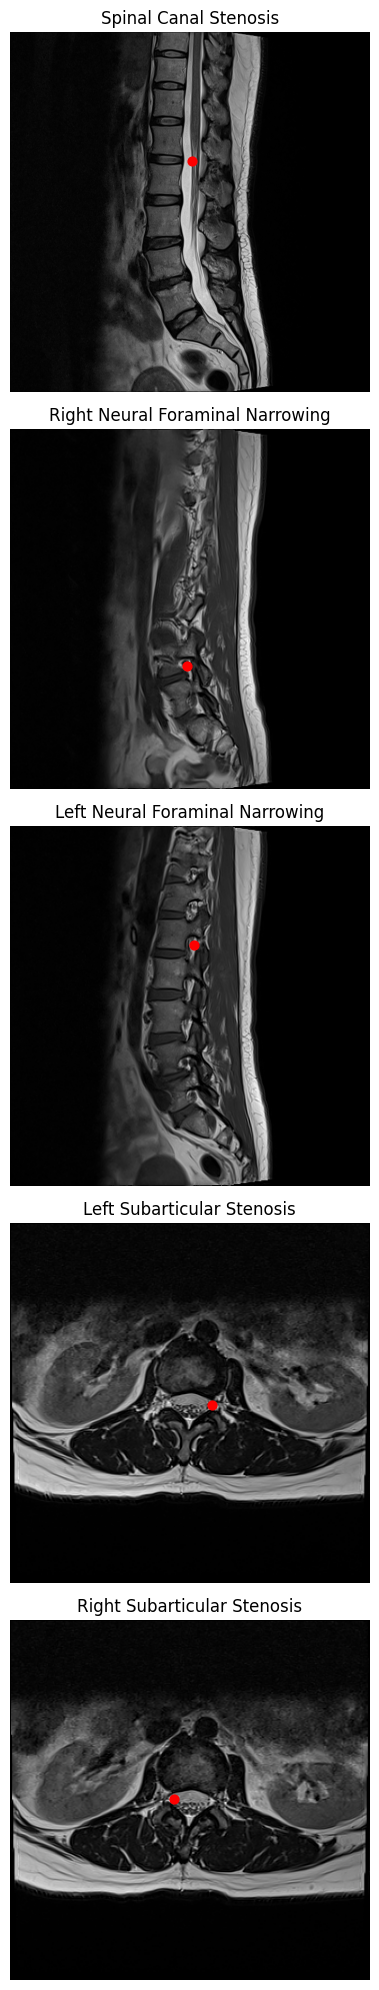

In [210]:
fig, axes = plt.subplots(
    len(conditions),
    1,
    figsize=(6, 4 * len(conditions))
)

if len(conditions) == 1:
    axes = [axes]

for ax, cond in zip(axes, conditions):

    row = master_df[master_df["condition"] == cond].iloc[0]

    folder = os.path.join(
        TRAIN_IMAGES,
        str(int(row.study_id)),
        str(int(row.series_id))
    )

    dcm = pydicom.dcmread(
        os.path.join(
            folder,
            f"{int(row.instance_number)}.dcm"
        )
    )

    ax.imshow(dcm.pixel_array, cmap="gray")
    ax.scatter(row.x, row.y, color="red", s=40)
    ax.set_title(cond)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Disease Frequency

In [211]:
condition_counts = master_df["condition"].value_counts()

condition_counts

condition
Left Neural Foraminal Narrowing     9860
Right Neural Foraminal Narrowing    9859
Spinal Canal Stenosis               9753
Right Subarticular Stenosis         9612
Left Subarticular Stenosis          9608
Name: count, dtype: int64

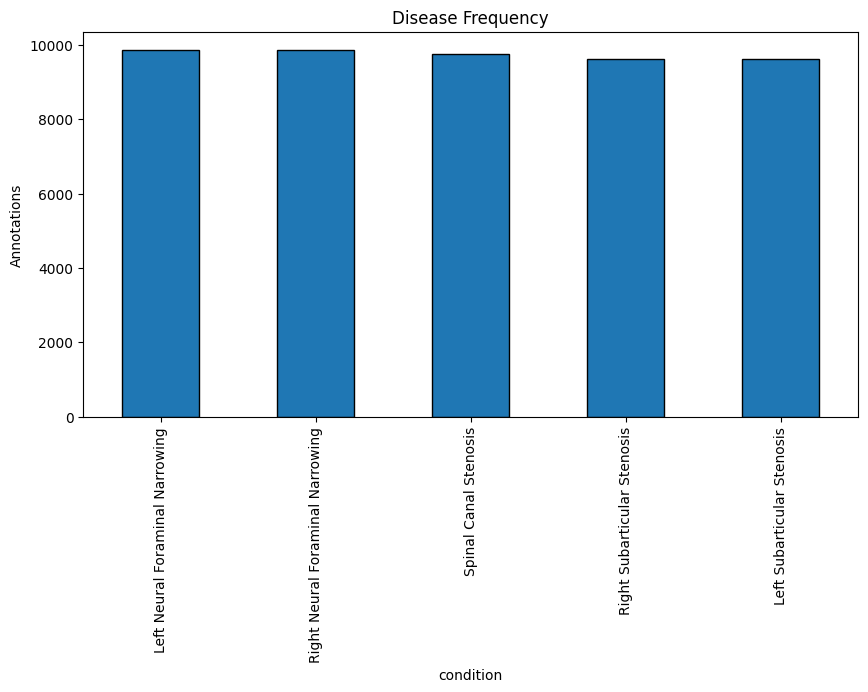

In [212]:
plt.figure(figsize=(10,5))

condition_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Disease Frequency")

plt.ylabel("Annotations")

plt.show()

In [213]:
condition_counts.to_csv(
    os.path.join(
        TABLE_DIR,
        "condition_counts.csv"
    )
)

## Disease-Level Distribution

In [214]:
pd.crosstab(
    master_df["condition"],
    master_df["level"]
)

level,L1/L2,L2/L3,L3/L4,L4/L5,L5/S1
condition,,,,,
Left Neural Foraminal Narrowing,1972,1972,1972,1972,1972
Left Subarticular Stenosis,1810,1892,1971,1971,1964
Right Neural Foraminal Narrowing,1972,1972,1971,1972,1972
Right Subarticular Stenosis,1812,1891,1971,1971,1967
Spinal Canal Stenosis,1904,1934,1973,1972,1970


In [215]:
cross = pd.crosstab(
    master_df["condition"],
    master_df["level"]
)

cross.to_csv(
    os.path.join(
        TABLE_DIR,
        "condition_level_table.csv"
    )
)

In [216]:
cross = pd.crosstab(
    master_df["condition"],
    master_df["level"]
)

cross.to_csv(
    os.path.join(
        TABLE_DIR,
        "condition_level_table.csv"
    )
)

## Verify MRI Sequences

In [217]:
master_df["series_description"].value_counts()

series_description
Sagittal T1         19724
Axial T2            19220
Sagittal T2/STIR     9748
Name: count, dtype: int64

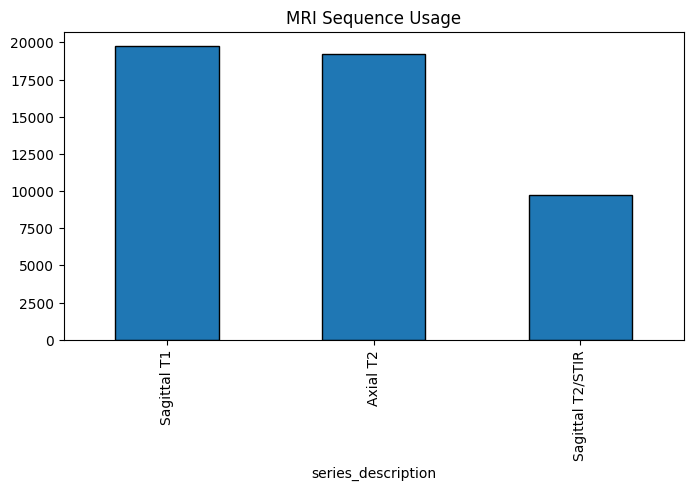

In [218]:
plt.figure(figsize=(8,4))

master_df["series_description"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("MRI Sequence Usage")

plt.show()

In [219]:
verification = pd.DataFrame({

    "Metric":[
        "Annotations",
        "Conditions",
        "Series",
        "Patients"
    ],

    "Value":[
        len(master_df),
        master_df.condition.nunique(),
        master_df.series_description.nunique(),
        master_df.study_id.nunique()
    ]

})

verification

,Metric,Value
0,Annotations,48692
1,Conditions,5
2,Series,3
3,Patients,1974


In [220]:
verification.to_csv(
    os.path.join(
        TABLE_DIR,
        "verification_summary.csv"
    ),
    index=False
)

## Module Summary

Completed:

- Loaded disease-specific MRI slices
- Located annotated DICOM files
- Displayed annotation coordinates
- Verified disease metadata
- Created disease statistics
- Prepared metadata for the Dataset class

## Next Module

Module 4 – Custom PyTorch Dataset

We will build a Dataset class that:

- Reads DICOM files
- Uses disease-specific annotated slices
- Applies preprocessing
- Converts images to tensors
- Returns image-label pairs for Swin UNETR

# Module 4: Custom PyTorch Dataset

## Objective

Create a PyTorch Dataset that:

- Reads DICOM images
- Uses annotation metadata
- Applies preprocessing
- Returns image tensor and metadata

This Dataset will later be used by the DataLoader.

In [221]:
# ============================================================
# Required Libraries
# ============================================================

import torch
from torch.utils.data import Dataset
from torchvision import transforms

import cv2
import pydicom
import numpy as np

In [222]:
# ============================================================
# Label Encoding
# ============================================================

label_mapping = {
    "Normal/Mild": 0,
    "Moderate": 1,
    "Severe": 2
}

# Mapping from annotation condition + level
# to the corresponding column in train.csv

condition_prefix = {
    "Spinal Canal Stenosis": "spinal_canal_stenosis",
    "Left Neural Foraminal Narrowing": "left_neural_foraminal_narrowing",
    "Right Neural Foraminal Narrowing": "right_neural_foraminal_narrowing",
    "Left Subarticular Stenosis": "left_subarticular_stenosis",
    "Right Subarticular Stenosis": "right_subarticular_stenosis"
}

print("Label mapping created.")

Label mapping created.


In [223]:
# ============================================================
# Image Size
# ============================================================

IMAGE_SIZE = 224

In [224]:
transform = None

## Helper Function

Load one DICOM slice from the annotation.

In [225]:
def load_three_slices(row):

    study_id = int(row["study_id"])
    series_id = int(row["series_id"])
    instance = int(row["instance_number"])

    folder = os.path.join(
        TRAIN_IMAGES,
        str(study_id),
        str(series_id)
    )

    dicom_files = sorted(
        [f for f in os.listdir(folder) if f.endswith(".dcm")],
        key=lambda x: int(x.replace(".dcm", ""))
    )

    slice_numbers = [
        int(f.replace(".dcm", ""))
        for f in dicom_files
    ]

    current_index = slice_numbers.index(instance)

    prev_index = max(current_index - 1, 0)
    next_index = min(current_index + 1, len(slice_numbers) - 1)

    indices = [
        prev_index,
        current_index,
        next_index
    ]

    images = []

    for idx in indices:

        path = os.path.join(
            folder,
            dicom_files[idx]
        )

        dcm = pydicom.dcmread(path)

        images.append(
            dcm.pixel_array
        )

    return images

## Image Preprocessing

In [226]:
def preprocess_image(images):

    processed = []

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    for image in images:

        image = image.astype(np.float32)

        image = (image-image.min()) / (
            image.max()-image.min()+1e-8
        )

        image = (image*255).astype(np.uint8)

        image = clahe.apply(image)

        image = cv2.resize(
            image,
            (224,224)
        )

        processed.append(image)

    processed = np.stack(
        processed,
        axis=-1
    )

    return processed

In [227]:
# ============================================================
# Get Severity Label (Safe Version)
# ============================================================

def get_target_label(row):

    condition = row["condition"]
    level = row["level"]

    # Map condition to train.csv column prefix
    prefix = condition_prefix.get(condition)

    if prefix is None:
        return -1

    # Convert level format (L1/L2 -> l1_l2)
    level = level.lower().replace("/", "_")

    column = f"{prefix}_{level}"

    study = row["study_id"]

    patient = train_df[
        train_df["study_id"] == study
    ]

    # Check if patient exists
    if patient.empty:
        return -1

    # Check if column exists
    if column not in train_df.columns:
        print(f"Column not found: {column}")
        return -1

    severity = patient.iloc[0][column]

    # Handle missing severity
    if pd.isna(severity):
        return -1

    # Handle unexpected label values
    if severity not in label_mapping:
        print(f"Unknown severity: {severity}")
        return -1

    return label_mapping[severity]

## Custom Dataset Class

In [228]:
# ============================================================
# Custom PyTorch Dataset
# ============================================================

class LumbarDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, index):

        # Get one annotation row
        row = self.df.iloc[index]

        # Load previous, current and next MRI slices
        images = load_three_slices(row)

        if images is None:
            raise FileNotFoundError(
                f"Unable to load MRI slices for index {index}"
            )

        # Preprocess the 3 slices
        image = preprocess_image(images)

        # Convert H × W × 3  -->  3 × H × W
        image = torch.tensor(
            image,
            dtype=torch.float32
        ).permute(2, 0, 1)

        # Normalize pixel values to [0,1]
        image = image / 255.0

        # Optional additional transforms
        if self.transform is not None:
            image = self.transform(image)

        # Get encoded target label
        label = torch.tensor(
            get_target_label(row),
            dtype=torch.long
        )

        sample = {

            "image": image,

            "label": label,

            "study_id": int(row["study_id"]),

            "series_id": int(row["series_id"]),

            "condition": row["condition"],

            "level": row["level"],

            "x": float(row["x"]),

            "y": float(row["y"])

        }

        return sample

In [229]:
# ============================================================
# Remove Samples with Missing Labels
# ============================================================

valid_rows = []

for _, row in master_df.iterrows():

    label = get_target_label(row)

    if label != -1:
        valid_rows.append(row)

master_df = pd.DataFrame(valid_rows).reset_index(drop=True)

print("Valid Samples :", len(master_df))

Valid Samples : 48657


In [230]:
dataset = LumbarDataset(
    master_df,
    transform=None
)

print("Dataset Size:", len(dataset))

Dataset Size: 48657


In [231]:
sample = dataset[0]

print(sample.keys())

print()

print("Encoded Label :", sample["label"])

dict_keys(['image', 'label', 'study_id', 'series_id', 'condition', 'level', 'x', 'y'])

Encoded Label : tensor(0)


In [232]:
print(sample["image"].shape)

torch.Size([3, 224, 224])


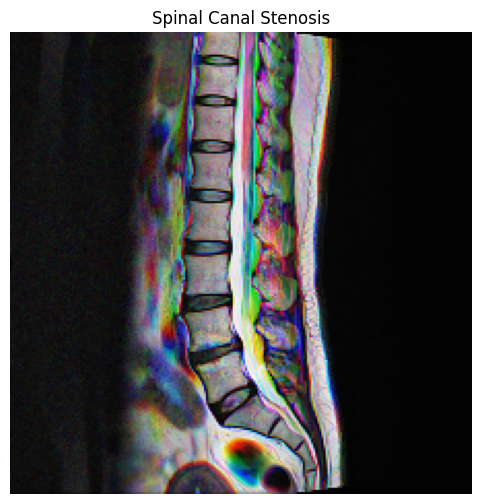

In [233]:
plt.figure(figsize=(6,6))

image = sample["image"].permute(1, 2, 0).numpy()

plt.imshow(image)

plt.title(sample["condition"])

plt.axis("off")

plt.show()

In [234]:
print("Study ID :", sample["study_id"])

print("Series ID :", sample["series_id"])

print("Condition :", sample["condition"])

print("Level :", sample["level"])

print("Encoded Label :", sample["label"].item())

Study ID : 4003253
Series ID : 702807833
Condition : Spinal Canal Stenosis
Level : L1/L2
Encoded Label : 0


In [235]:
for i in range(3):

    s = dataset[i]

    print("="*40)

    print("Study :", s["study_id"])
    print("Condition :", s["condition"])
    print("Level :", s["level"])

Study : 4003253
Condition : Spinal Canal Stenosis
Level : L1/L2
Study : 4003253
Condition : Spinal Canal Stenosis
Level : L2/L3
Study : 4003253
Condition : Spinal Canal Stenosis
Level : L3/L4


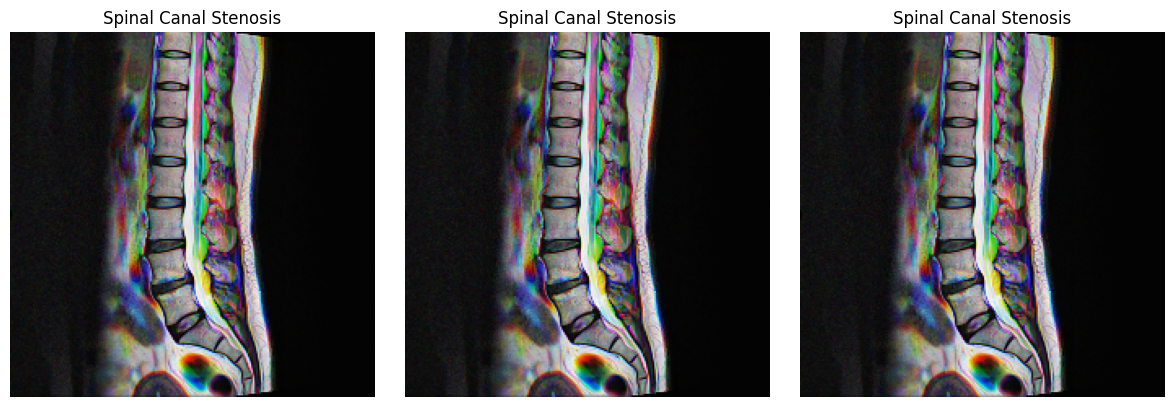

In [236]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, idx in zip(axes, [0, 1, 2]):

    s = dataset[idx]

    image = s["image"].permute(1, 2, 0).numpy()

    ax.imshow(image)

    ax.set_title(s["condition"])

    ax.axis("off")

plt.tight_layout()

plt.show()

In [237]:
summary = pd.DataFrame({

    "Metric":[
        "Dataset Size",
        "Image Size",
        "Unique Patients",
        "Unique Conditions"
    ],

    "Value":[
        len(dataset),
        "224 x 224",
        master_df.study_id.nunique(),
        master_df.condition.nunique()
    ]

})

summary

,Metric,Value
0,Dataset Size,48657
1,Image Size,224 x 224
2,Unique Patients,1974
3,Unique Conditions,5


In [238]:
summary.to_csv(
    os.path.join(
        TABLE_DIR,
        "dataset_summary_module4.csv"
    ),
    index=False
)

## Module Summary

Completed:

- Built custom Dataset
- Loaded DICOM images
- Applied preprocessing
- Converted to tensors
- Returned metadata
- Verified sample loading

## Next Module

Module 5: DataLoader

We will:

- Split the dataset
- Create training and validation loaders
- Define batch size
- Verify batches

# Module 5: DataLoader Creation

## Objective

Create efficient PyTorch DataLoaders for:

- Training
- Validation

The DataLoader will be used directly during Swin UNETR training.

In [239]:
# ============================================================
# Required Libraries
# ============================================================

from torch.utils.data import random_split
from torch.utils.data import DataLoader

In [240]:
# ============================================================
# Dataset Size
# ============================================================

dataset_size = len(dataset)

print("Dataset Size :", dataset_size)

Dataset Size : 48657


## Train / Validation Split

In [241]:
train_size = int(0.8 * dataset_size)

valid_size = dataset_size - train_size

print("Training Samples :", train_size)

print("Validation Samples :", valid_size)

Training Samples : 38925
Validation Samples : 9732


In [242]:
torch.manual_seed(42)

train_dataset, valid_dataset = random_split(

    dataset,

    [train_size, valid_size]

)

print("Split Completed")

Split Completed


In [243]:
print("Training Dataset :", len(train_dataset))

print("Validation Dataset :", len(valid_dataset))

Training Dataset : 38925
Validation Dataset : 9732


## Batch Size

RTX 2050 (4 GB VRAM)

Recommended:

Batch Size = 4

In [244]:
BATCH_SIZE = 4

In [245]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

In [246]:
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

In [247]:
print("Training Batches :", len(train_loader))

print("Validation Batches :", len(valid_loader))

Training Batches : 9732
Validation Batches : 2433


## Verify One Batch

In [248]:
batch = next(iter(train_loader))

In [249]:
print(batch.keys())

dict_keys(['image', 'label', 'study_id', 'series_id', 'condition', 'level', 'x', 'y'])


In [250]:
print(batch["image"].shape)

torch.Size([4, 3, 224, 224])


In [251]:
print("Labels")

print(batch["label"])

Labels
tensor([1, 2, 1, 0])


In [252]:
print(batch["level"])

['L4/L5', 'L4/L5', 'L4/L5', 'L1/L2']


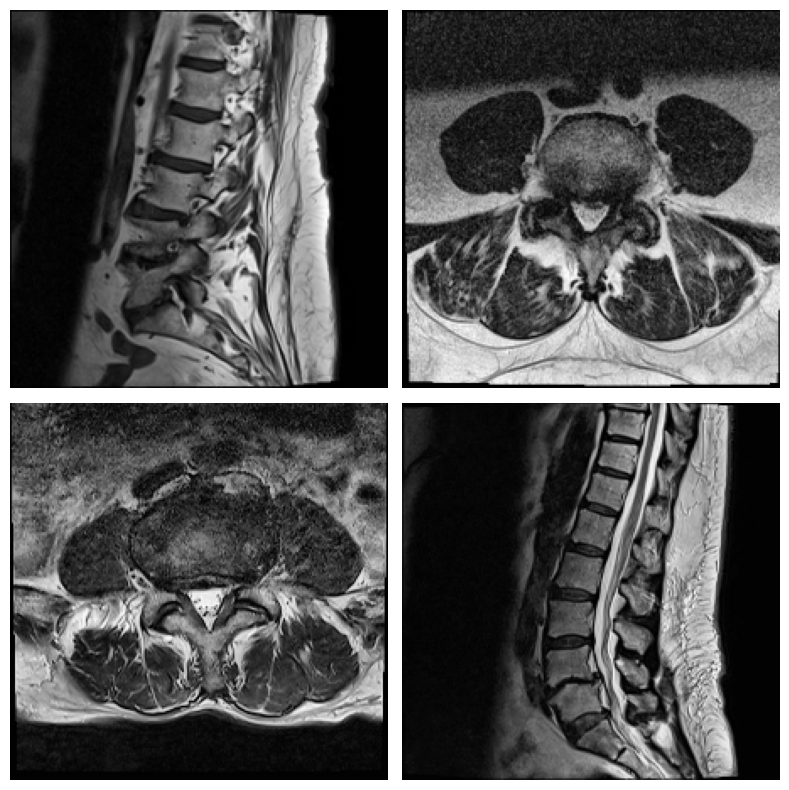

In [253]:
fig, axes = plt.subplots(2,2, figsize=(8,8))

for ax, img in zip(

    axes.flat,

    batch["image"]

):

    ax.imshow(img[1].numpy(), cmap="gray")

    ax.axis("off")

plt.tight_layout()

plt.show()

In [254]:
for i in range(BATCH_SIZE):

    print("="*40)

    print("Study :", batch["study_id"][i].item())

    print("Condition :", batch["condition"][i])

    print("Level :", batch["level"][i])

    print("Encoded Label :", batch["label"][i].item())

Study : 3068678959
Condition : Right Neural Foraminal Narrowing
Level : L4/L5
Encoded Label : 1
Study : 3836986623
Condition : Left Subarticular Stenosis
Level : L4/L5
Encoded Label : 2
Study : 329807127
Condition : Left Subarticular Stenosis
Level : L4/L5
Encoded Label : 1
Study : 2370517350
Condition : Spinal Canal Stenosis
Level : L1/L2
Encoded Label : 0


## DataLoader Statistics

In [255]:
loader_summary = pd.DataFrame({

    "Metric":[

        "Training Samples",

        "Validation Samples",

        "Batch Size",

        "Training Batches",

        "Validation Batches"

    ],

    "Value":[

        len(train_dataset),

        len(valid_dataset),

        BATCH_SIZE,

        len(train_loader),

        len(valid_loader)

    ]

})

loader_summary

,Metric,Value
0,Training Samples,38925
1,Validation Samples,9732
2,Batch Size,4
3,Training Batches,9732
4,Validation Batches,2433


In [256]:
loader_summary.to_csv(

    os.path.join(

        TABLE_DIR,

        "dataloader_summary.csv"

    ),

    index=False

)

In [257]:
print("="*60)

print("DataLoader Successfully Created")

print("="*60)

DataLoader Successfully Created


In [258]:
print("Batch Tensor Shape")

print(batch["image"].shape)

Batch Tensor Shape
torch.Size([4, 3, 224, 224])


In [259]:
print("Image Data Type")

print(batch["image"].dtype)

Image Data Type
torch.float32


In [260]:
print("Minimum Pixel :", batch["image"].min())

print("Maximum Pixel :", batch["image"].max())

Minimum Pixel : tensor(0.0039)
Maximum Pixel : tensor(0.9961)


## Module Summary

Completed:

- Train/Validation split
- DataLoader creation
- Batch verification
- Sample visualization
- Saved DataLoader summary

## Next Module

Module 6 – Batch Visualization & Dataset Verification

We will:

- Visualize multiple batches
- Verify tensor dimensions
- Analyze disease distribution
- Check class balance
- Prepare the dataset for Swin UNETR training

# Module 6: Batch Visualization & Dataset Verification

## Objective

This module verifies the complete data pipeline before model training.

Verification includes:

- Image tensors
- Encoded labels
- Batch statistics
- Disease distribution
- DataLoader correctness

In [261]:
# ============================================================
# Load One Training Batch
# ============================================================

batch = next(iter(train_loader))

print("Batch Loaded Successfully")

Batch Loaded Successfully


In [262]:
print(batch.keys())

dict_keys(['image', 'label', 'study_id', 'series_id', 'condition', 'level', 'x', 'y'])


In [263]:
print("Image Batch Shape :", batch["image"].shape)

print("Label Shape :", batch["label"].shape)

Image Batch Shape : torch.Size([4, 3, 224, 224])
Label Shape : torch.Size([4])


In [264]:
print("Tensor Type :", batch["image"].dtype)

print("Label Type :", batch["label"].dtype)

Tensor Type : torch.float32
Label Type : torch.int64


In [265]:
print("Minimum Pixel :", batch["image"].min().item())

print("Maximum Pixel :", batch["image"].max().item())

print("Mean Pixel :", batch["image"].mean().item())

print("Std Pixel :", batch["image"].std().item())

Minimum Pixel : 0.0
Maximum Pixel : 1.0
Mean Pixel : 0.2387213408946991
Std Pixel : 0.23514913022518158


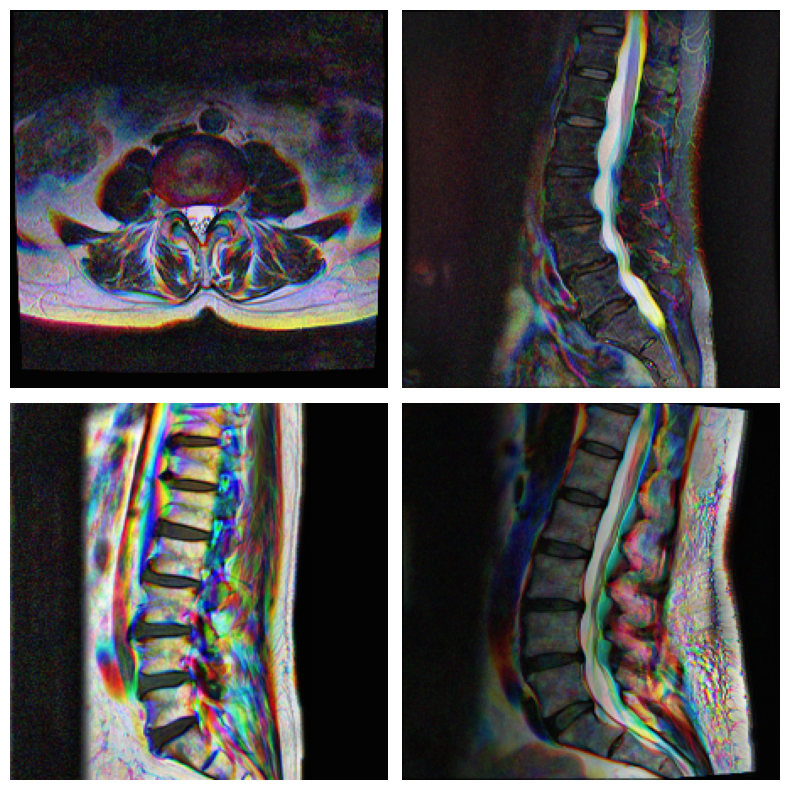

In [266]:
fig, axes = plt.subplots(

    2,

    2,

    figsize=(8,8)

)

for ax, img in zip(

    axes.flat,

    batch["image"]

):

    ax.imshow(
    img.permute(1,2,0).numpy()
)

    ax.axis("off")

plt.tight_layout()

plt.show()

In [267]:
for i in range(BATCH_SIZE):

    print("="*50)

    print("Study ID :", batch["study_id"][i].item())

    print("Series ID :", batch["series_id"][i].item())

    print("Condition :", batch["condition"][i])

    print("Level :", batch["level"][i])

    print("Encoded Label :", batch["label"][i].item())

Study ID : 2730815103
Series ID : 2082831806
Condition : Left Subarticular Stenosis
Level : L3/L4
Encoded Label : 0
Study ID : 3659501484
Series ID : 230328343
Condition : Spinal Canal Stenosis
Level : L1/L2
Encoded Label : 0
Study ID : 765167979
Series ID : 4453863
Condition : Right Neural Foraminal Narrowing
Level : L3/L4
Encoded Label : 1
Study ID : 309197706
Series ID : 383794398
Condition : Spinal Canal Stenosis
Level : L3/L4
Encoded Label : 0


In [268]:
label_names = {

    0: "Normal/Mild",

    1: "Moderate",

    2: "Severe"

}

decoded = [

    label_names[int(i)]

    for i in batch["label"]

]

decoded

['Normal/Mild', 'Normal/Mild', 'Moderate', 'Normal/Mild']

In [269]:
verification_df = pd.DataFrame({

    "Study ID": batch["study_id"],

    "Condition": batch["condition"],

    "Level": batch["level"],

    "Encoded Label": batch["label"],

    "Severity": decoded

})

verification_df

,Study ID,Condition,Level,Encoded Label,Severity
0,2730815103,Left Subarticular Stenosis,L3/L4,0,Normal/Mild
1,3659501484,Spinal Canal Stenosis,L1/L2,0,Normal/Mild
2,765167979,Right Neural Foraminal Narrowing,L3/L4,1,Moderate
3,309197706,Spinal Canal Stenosis,L3/L4,0,Normal/Mild


In [270]:
verification_df.to_csv(

    os.path.join(

        TABLE_DIR,

        "batch_verification.csv"

    ),

    index=False

)

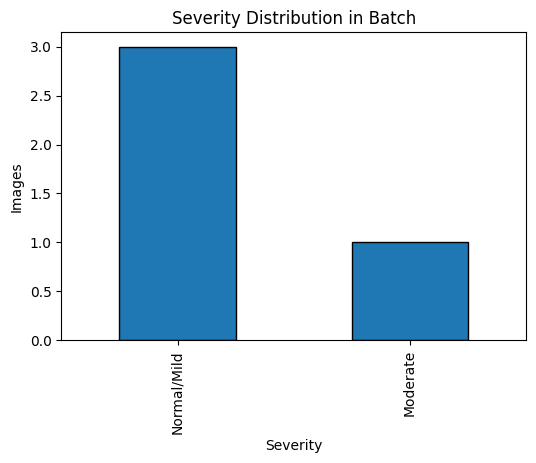

In [271]:
plt.figure(figsize=(6,4))

verification_df["Severity"].value_counts().plot(

    kind="bar",

    edgecolor="black"

)

plt.title("Severity Distribution in Batch")

plt.ylabel("Images")

plt.show()

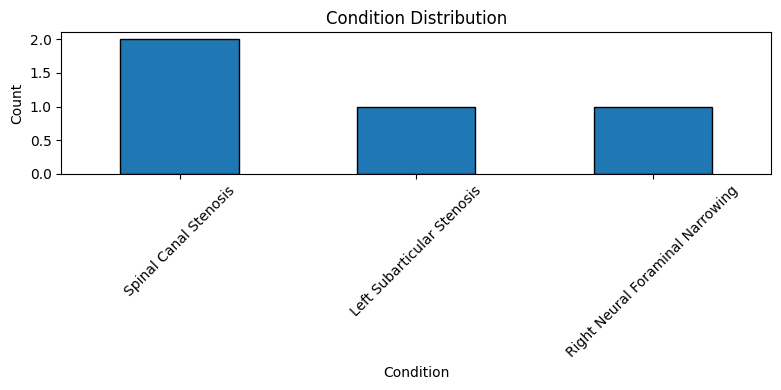

In [272]:
plt.figure(figsize=(8,4))

verification_df["Condition"].value_counts().plot(

    kind="bar",

    edgecolor="black"

)

plt.title("Condition Distribution")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [273]:
summary = pd.DataFrame({

    "Metric":[

        "Dataset Size",

        "Training Samples",

        "Validation Samples",

        "Batch Size",

        "Unique Conditions",

        "Unique Severity Labels"

    ],

    "Value":[

        len(dataset),

        len(train_dataset),

        len(valid_dataset),

        BATCH_SIZE,

        master_df.condition.nunique(),

        len(label_mapping)

    ]

})

summary

,Metric,Value
0,Dataset Size,48657
1,Training Samples,38925
2,Validation Samples,9732
3,Batch Size,4
4,Unique Conditions,5
5,Unique Severity Labels,3


In [274]:
summary.to_csv(

    os.path.join(

        TABLE_DIR,

        "dataset_verification_summary.csv"

    ),

    index=False

)

In [275]:
print("="*60)

print("Dataset Verification Completed")

print("="*60)

Dataset Verification Completed


In [276]:
print("Image Tensor Shape")

print(batch["image"].shape)

print()

print("Image Tensor Type")

print(batch["image"].dtype)

print()

print("Label Tensor Shape")

print(batch["label"].shape)

print()

print("Label Tensor Type")

print(batch["label"].dtype)

Image Tensor Shape
torch.Size([4, 3, 224, 224])

Image Tensor Type
torch.float32

Label Tensor Shape
torch.Size([4])

Label Tensor Type
torch.int64


In [277]:
print("GPU Available :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU Name :", torch.cuda.get_device_name(0))

GPU Available : True
GPU Name : NVIDIA GeForce RTX 2050


torch.Size([3, 224, 224])


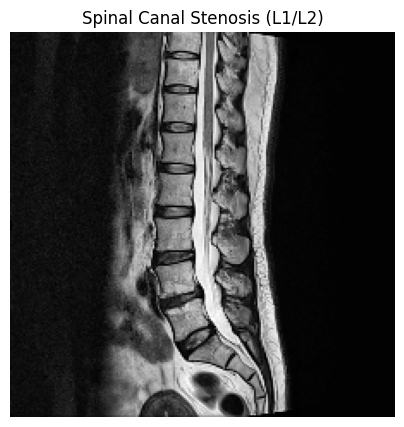

In [278]:
# ============================================================
# Display Middle (Annotated) Slice
# ============================================================

sample = dataset[0]

sample_image = sample["image"]

print(sample_image.shape)

plt.figure(figsize=(5,5))

plt.imshow(
    sample_image[1].cpu().numpy(),
    cmap="gray"
)

plt.title(f"{sample['condition']} ({sample['level']})")

plt.axis("off")

plt.show()

In [279]:
print("Everything is ready for Swin UNETR Training.")

Everything is ready for Swin UNETR Training.


# Module Summary

Completed:

- Verified Dataset
- Verified DataLoader
- Verified Labels
- Verified Tensor Shapes
- Verified Image Quality
- Verified GPU Compatibility

# Notebook 5 Completed

Outputs Generated:

- master_dataframe.csv
- dataset_summary.csv
- dataloader_summary.csv
- batch_verification.csv
- dataset_verification_summary.csv

Next Notebook:

Notebook 6

## Swin UNETR Model Implementation

Topics:

- Swin UNETR Architecture
- MONAI Integration
- Loss Function
- Optimizer
- Training Loop
- Validation
- Metrics
- Model Saving

# Final Validation

## Objective

Verify that the complete data pipeline is working correctly.

Checks include:

- Dataset integrity
- DICOM loading
- Tensor shapes
- Label encoding
- DataLoader
- Missing files
- GPU compatibility

In [280]:
print("="*60)
print("FINAL VALIDATION")
print("="*60)

print("Dataset Size :", len(dataset))
print("Training Samples :", len(train_dataset))
print("Validation Samples :", len(valid_dataset))
print("Batch Size :", BATCH_SIZE)

FINAL VALIDATION
Dataset Size : 48657
Training Samples : 38925
Validation Samples : 9732
Batch Size : 4


In [281]:
print(master_df.shape)

master_df.head()

(48657, 34)


,study_id,series_id,instance_number,condition,level,x,y,series_description,encoded_label,spinal_canal_stenosis_l1_l2,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
0,4003253,702807833,8,Spinal Canal Stenosis,L1/L2,322.831858,227.964602,Sagittal T2/STIR,Ellipsis,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
1,4003253,702807833,8,Spinal Canal Stenosis,L2/L3,320.571429,295.714286,Sagittal T2/STIR,Ellipsis,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
2,4003253,702807833,8,Spinal Canal Stenosis,L3/L4,323.030303,371.818182,Sagittal T2/STIR,Ellipsis,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
3,4003253,702807833,8,Spinal Canal Stenosis,L4/L5,335.292035,427.327434,Sagittal T2/STIR,Ellipsis,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
4,4003253,702807833,8,Spinal Canal Stenosis,L5/S1,353.415929,483.964602,Sagittal T2/STIR,Ellipsis,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild


In [282]:
print(master_df.isnull().sum())

study_id                                     0
series_id                                    0
instance_number                              0
condition                                    0
level                                        0
x                                            0
y                                            0
series_description                           0
encoded_label                                0
spinal_canal_stenosis_l1_l2                  0
spinal_canal_stenosis_l2_l3                  0
spinal_canal_stenosis_l3_l4                  0
spinal_canal_stenosis_l4_l5                  0
spinal_canal_stenosis_l5_s1                  0
left_neural_foraminal_narrowing_l1_l2       30
left_neural_foraminal_narrowing_l2_l3       30
left_neural_foraminal_narrowing_l3_l4       30
left_neural_foraminal_narrowing_l4_l5       30
left_neural_foraminal_narrowing_l5_s1       30
right_neural_foraminal_narrowing_l1_l2     150
right_neural_foraminal_narrowing_l2_l3     150
right_neural_

In [283]:
print(train_df.shape)

print(series_df.shape)

print(coord_df.shape)

(1975, 26)
(6294, 3)
(48692, 7)


In [284]:
print("Unique Patients :", master_df.study_id.nunique())

print("Unique MRI Series :", master_df.series_id.nunique())

print("Unique Conditions :", master_df.condition.nunique())

print("Unique Levels :", master_df.level.nunique())

Unique Patients : 1974
Unique MRI Series : 6290
Unique Conditions : 5
Unique Levels : 5


In [285]:
batch = next(iter(train_loader))

print(batch.keys())

dict_keys(['image', 'label', 'study_id', 'series_id', 'condition', 'level', 'x', 'y'])


In [286]:
print(batch["image"].shape)

print(batch["label"].shape)

torch.Size([4, 3, 224, 224])
torch.Size([4])


In [287]:
print(batch["image"].dtype)

print(batch["label"].dtype)

torch.float32
torch.int64


In [288]:
print("Minimum :", batch["image"].min().item())

print("Maximum :", batch["image"].max().item())

print("Mean :", batch["image"].mean().item())

print("Std :", batch["image"].std().item())

Minimum : 0.003921568859368563
Maximum : 0.9960784316062927
Mean : 0.23864540457725525
Std : 0.22399911284446716


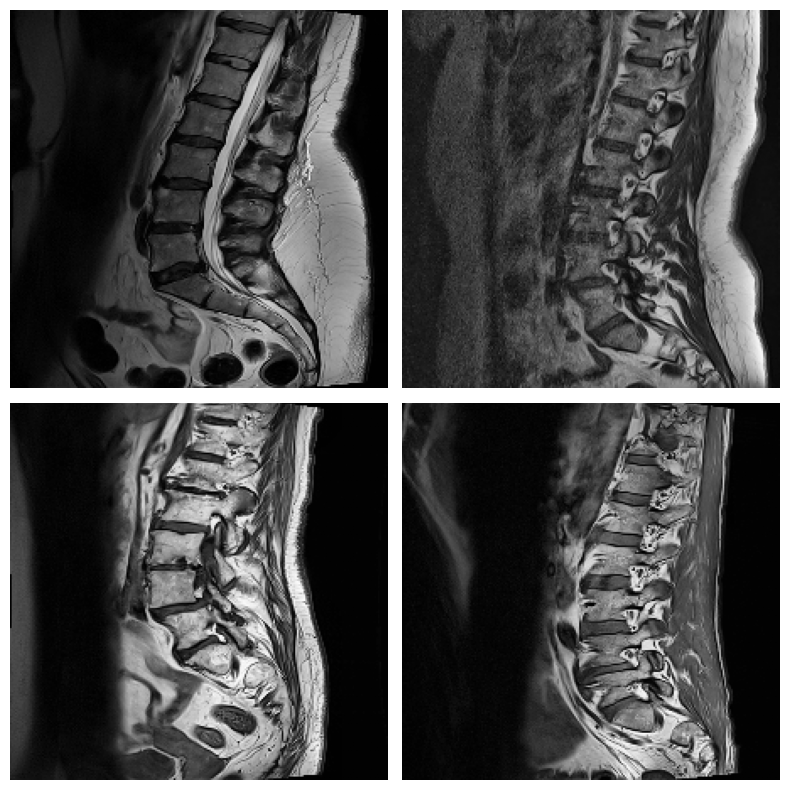

In [289]:
fig, axes = plt.subplots(

    2,

    2,

    figsize=(8,8)

)

for ax, img in zip(

    axes.flat,

    batch["image"]

):

    ax.imshow(img[1].numpy(), cmap="gray")

    ax.axis("off")

plt.tight_layout()

plt.show()

In [290]:
for i in range(BATCH_SIZE):

    print("="*40)

    print("Study :", batch["study_id"][i].item())

    print("Series :", batch["series_id"][i].item())

    print("Condition :", batch["condition"][i])

    print("Level :", batch["level"][i])

    print("Label :", batch["label"][i].item())

Study : 3429410502
Series : 3606206449
Condition : Spinal Canal Stenosis
Level : L4/L5
Label : 0
Study : 1650340034
Series : 3305241166
Condition : Right Neural Foraminal Narrowing
Level : L5/S1
Label : 0
Study : 2918963439
Series : 3182420942
Condition : Right Neural Foraminal Narrowing
Level : L1/L2
Label : 1
Study : 979209761
Series : 360631587
Condition : Left Neural Foraminal Narrowing
Level : L2/L3
Label : 0


In [291]:
print("CUDA Available :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU :", torch.cuda.get_device_name(0))

    print("CUDA Version :", torch.version.cuda)

CUDA Available : True
GPU : NVIDIA GeForce RTX 2050
CUDA Version : 12.8


In [292]:
print("Total Batches :", len(train_loader))

Total Batches : 9732


In [293]:
import random

print("Checking 20 random batches...\n")

train_iter = iter(train_loader)

success = 0

for i in range(20):

    try:

        batch = next(train_iter)

        success += 1

        print(f"Batch {i+1} : OK")

    except StopIteration:

        break

    except Exception as e:

        print(f"Batch {i+1} : ERROR")

        print(e)

print()

print(f"Successfully Loaded {success} batches.")

Checking 20 random batches...

Batch 1 : OK
Batch 2 : OK
Batch 3 : OK
Batch 4 : OK
Batch 5 : OK
Batch 6 : OK
Batch 7 : OK
Batch 8 : OK
Batch 9 : OK
Batch 10 : OK
Batch 11 : OK
Batch 12 : OK
Batch 13 : OK
Batch 14 : OK
Batch 15 : OK
Batch 16 : OK
Batch 17 : OK
Batch 18 : OK
Batch 19 : OK
Batch 20 : OK

Successfully Loaded 20 batches.


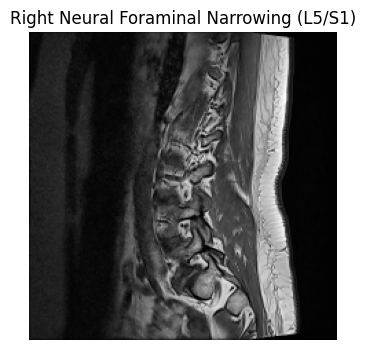

Study ID : 3880626718
Series ID : 1310605220
Label : 0
--------------------------------------------------


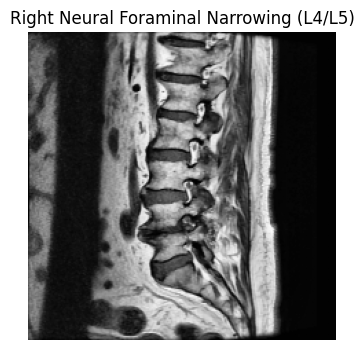

Study ID : 1217477368
Series ID : 3518039320
Label : 1
--------------------------------------------------


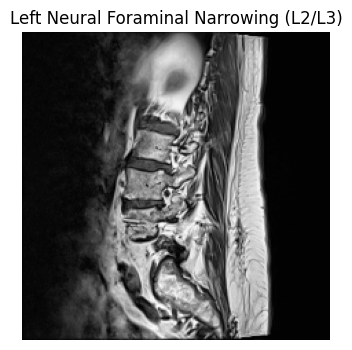

Study ID : 3133422961
Series ID : 468775854
Label : 0
--------------------------------------------------


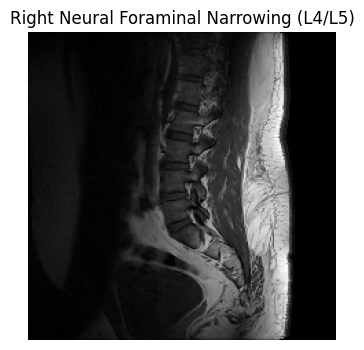

Study ID : 3132121971
Series ID : 3395388661
Label : 0
--------------------------------------------------


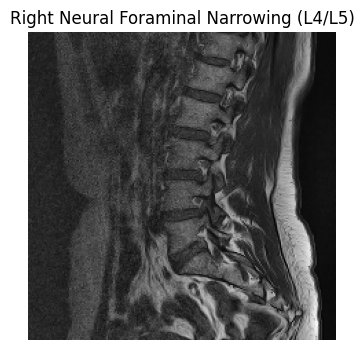

Study ID : 893250212
Series ID : 2994778958
Label : 1
--------------------------------------------------


In [294]:
# ============================================================
# Display Random Dataset Samples
# ============================================================

import random

indices = random.sample(range(len(dataset)), 5)

for idx in indices:

    sample = dataset[idx]

    image = sample["image"]      # PyTorch Tensor [3,224,224]

    plt.figure(figsize=(4,4))

    plt.imshow(
        image[1].cpu().numpy(),   # Middle (annotated) slice
        cmap="gray"
    )

    plt.title(
        f"{sample['condition']} ({sample['level']})"
    )

    plt.axis("off")

    plt.show()

    print("Study ID :", sample["study_id"])
    print("Series ID :", sample["series_id"])
    print("Label :", sample["label"].item())
    print("-"*50)

In [295]:
validation_summary = pd.DataFrame({

    "Metric":[

        "Dataset Size",

        "Train Samples",

        "Validation Samples",

        "Batch Size",

        "GPU",

        "CUDA"

    ],

    "Value":[

        len(dataset),

        len(train_dataset),

        len(valid_dataset),

        BATCH_SIZE,

        torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",

        torch.cuda.is_available()

    ]

})

validation_summary

,Metric,Value
0,Dataset Size,48657
1,Train Samples,38925
2,Validation Samples,9732
3,Batch Size,4
4,GPU,NVIDIA GeForce RTX 2050
5,CUDA,True


In [296]:
validation_summary.to_csv(

    os.path.join(

        TABLE_DIR,

        "final_validation.csv"

    ),

    index=False

)

print("Final Validation Report Saved.")

Final Validation Report Saved.


In [297]:
print("="*60)
print("FINAL CHECKLIST")
print("="*60)

print("✓ CSV files loaded")
print("✓ DICOM files accessible")
print("✓ Images preprocessed")
print("✓ Labels encoded")
print("✓ Dataset created")
print("✓ DataLoader created")
print("✓ GPU detected")
print("✓ Ready for Swin UNETR")
print("="*60)

FINAL CHECKLIST
✓ CSV files loaded
✓ DICOM files accessible
✓ Images preprocessed
✓ Labels encoded
✓ Dataset created
✓ DataLoader created
✓ GPU detected
✓ Ready for Swin UNETR
